In [4]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("4x4_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

Vi = dat["V_i"]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3003
1187


# Analysis

## Coordinate chart

| 1 | 2 | 3 | 4 |
|---|---|---|---|
| 5 | 6 | 7 | 8 |
| 9 | 10 | 11 | 12 |
| 13 | 14 | 15 | 16 |

## Single trap depth

Text(0, 0.5, 'U')

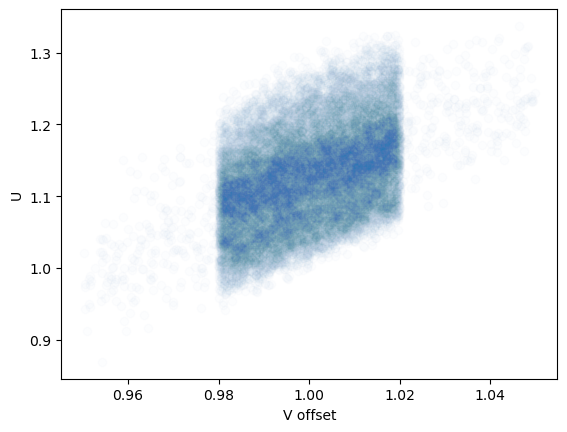

In [38]:
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), alpha=1e-2)
plt.xlabel("V offset")
plt.ylabel("U")

## Position effect

### Average U over grid

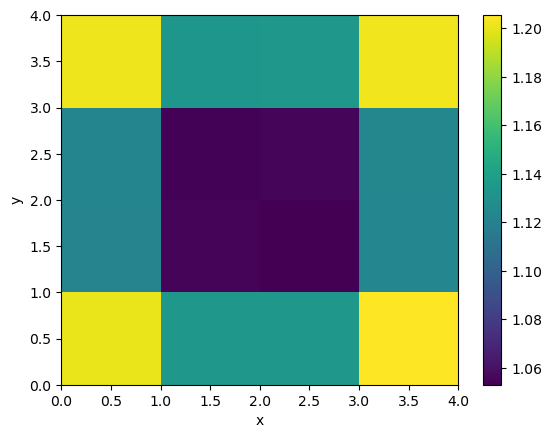

In [3]:
avgU = np.mean(dat["U_i"][mask], axis=0)
plt.pcolormesh(avgU.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

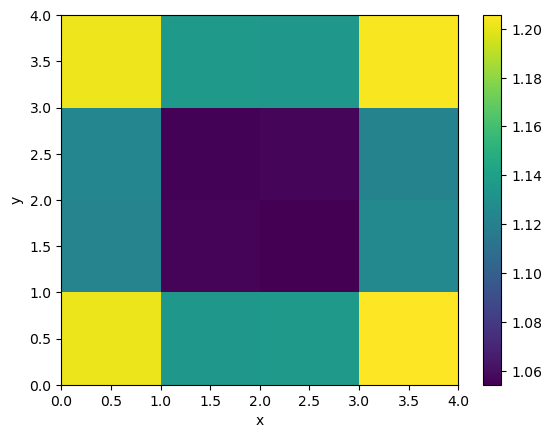

In [40]:
avgU = np.median(dat["U_i"][mask], axis=0)
plt.pcolormesh(avgU.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

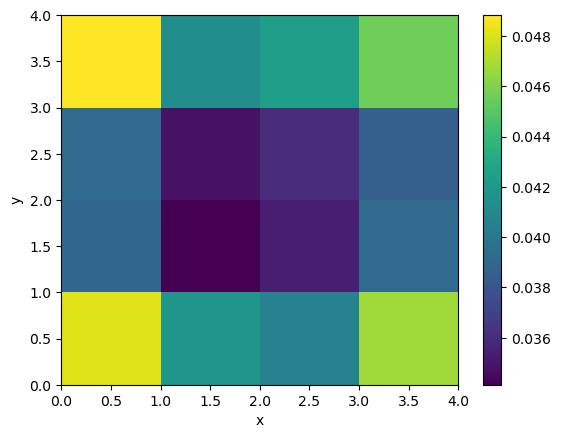

In [39]:
avgU = np.std(dat["U_i"][mask], axis=0)
plt.pcolormesh(avgU.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

This clearly indicate that one descrptor is the number of neighbors.

### Site index

In [3]:
avgU = np.mean(dat["U_i"][mask], axis=0)

Text(0, 0.5, 'U_i')

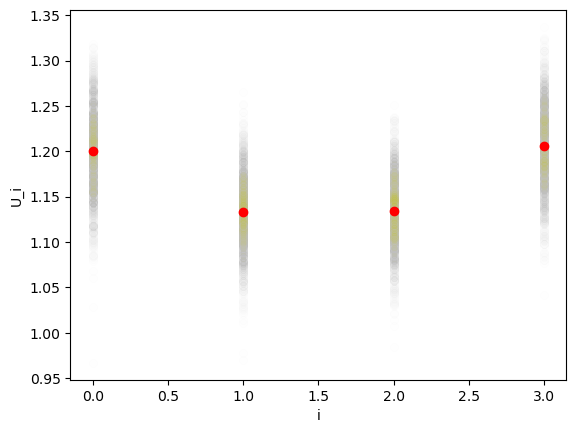

In [4]:
sidx = list(range(4))
plt.scatter(
    np.tile(sidx, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=2e-3
)
plt.scatter(sidx, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("i")
plt.ylabel("U_i")

Text(0, 0.5, 'U_i')

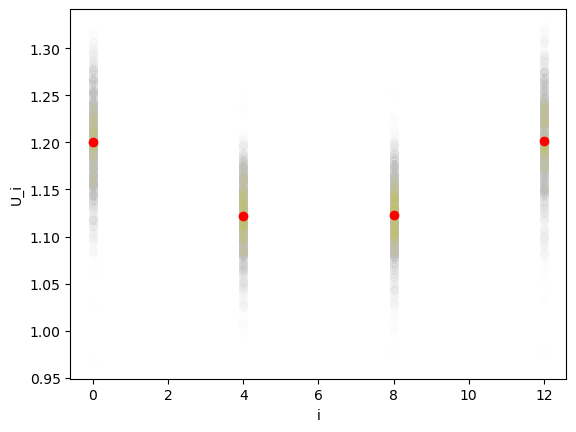

In [5]:
sidx = list(range(0, 16, 4))
plt.scatter(
    np.tile(sidx, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=2e-3
)
plt.scatter(sidx, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("i")
plt.ylabel("U_i")

Text(0, 0.5, 'U_i')

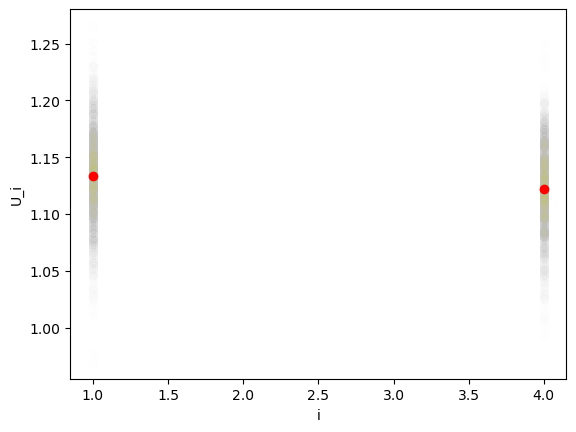

In [6]:
sidx = [1, 4]
plt.scatter(
    np.tile(sidx, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=2e-3
)
plt.scatter(sidx, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("i")
plt.ylabel("U_i")

### Neighboring number

In [7]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


nn = nneighbor(width, height)
print(nn)

[2 3 3 2 3 4 4 3 3 4 4 3 2 3 3 2]


Text(0, 0.5, 'U_i')

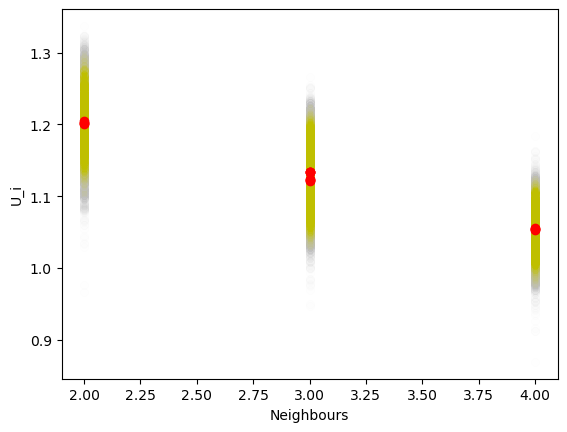

In [8]:
sidx = list(range(16))
plt.scatter(
    np.tile(nn, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=2e-3
)
plt.scatter(nn, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("Neighbours")
plt.ylabel("U_i")

### Average trap spacing

The sum of trap spacing is a factor to count both the number of neighbors and the average trap spacing.

In [9]:
from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


avgr = avg_trap_spacing(np.arange(16))

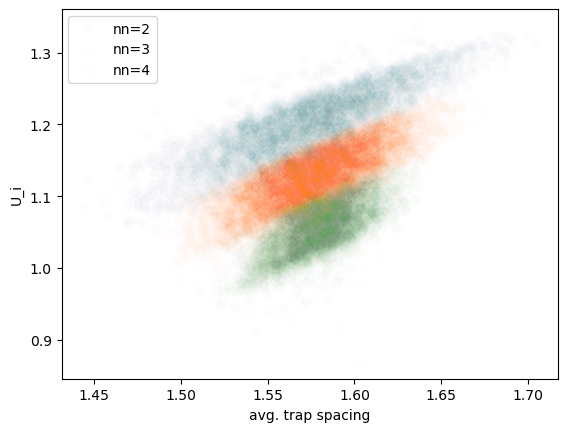

In [14]:
for i in [2, 3, 4]:
    plt.scatter(
        avgr.T[:, nn == i],
        dat["U_i"][mask][:, nn == i].flatten(),
        alpha=8e-3,
        label=f"nn={i}",
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

Average trap spacing is a linear factor.

What about total spacing?

In [15]:
from typing import Iterable


def tot_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([tot_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    totr = np.sum(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return totr


totr = tot_trap_spacing(np.arange(16))

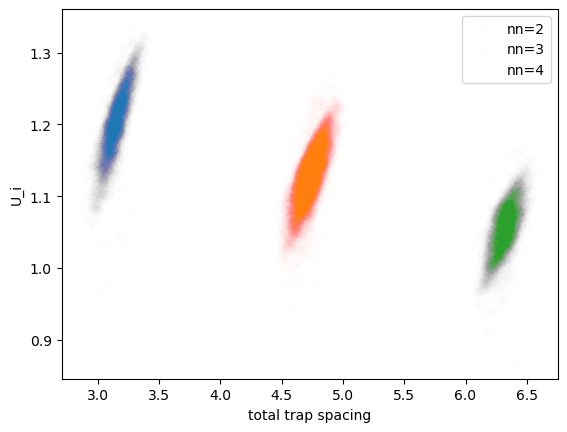

In [17]:
for i in [2, 3, 4]:
    plt.scatter(
        totr.T[:, nn == i],
        dat["U_i"][mask][:, nn == i].flatten(),
        alpha=2e-3,
        label=f"nn={i}",
    )
plt.xlabel("total trap spacing")
plt.ylabel("U_i")
plt.legend()

V_offset correlation to nno.

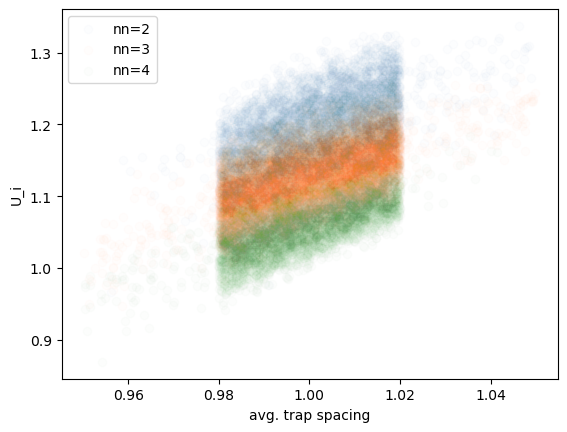

In [19]:
for i in [2, 3, 4]:
    plt.scatter(
        dat["V_offset"][mask][:, nn == i],
        dat["U_i"][mask][:, nn == i].flatten(),
        alpha=1e-2,
        label=f"nn={i}",
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

## Total trap depth

In [20]:
# zR = 4 * np.ones(2)
wxy = np.ones(2)
# zR0 = np.prod(zR) / np.linalg.norm(zR)
width = 4
height = 4
N = width * height
dim = 3


# def Vfun(x, y, z):
#     d0 = 1 + (z / zR0) ** 2 / 2
#     dxy = (x / wxy[0]) ** 2 / (1 + (z / zR[0]) ** 2)
#     dxy += (y / wxy[1]) ** 2 / (1 + (z / zR[1]) ** 2)
#     V = -1 / d0 * np.exp(-2 * dxy)
#     return V


def Vfun(x, y):
    dxy = x**2 + y**2
    V = -np.exp(-2 * dxy)
    return V


def tot_trap_depth(V0, trap_centers):
    # tc = np.zeros((N, dim))
    tc = np.zeros((N, 2))
    vij = np.ones((N, N))
    for i in range(N):
        # tc[i, :] = np.append(trap_centers[i], 0)
        tc[i, :] = trap_centers[i]
        for j in range(i):
            vij[i, j] = -Vfun(*(tc[i] - tc[j]))
            vij[j, i] = vij[i, j]  # Potential is symmetric in distance
    vtot = vij @ V0
    return vtot


vtot = np.array(
    list(map(tot_trap_depth, dat["V_offset"][mask], dat["trap_centers"][mask]))
)

Text(0, 0.5, 'U_i')

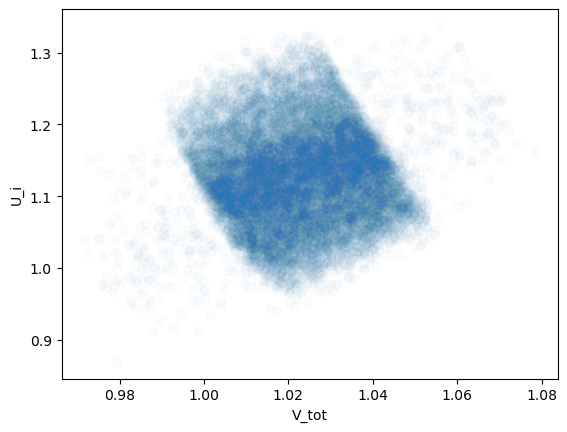

In [21]:
plt.scatter(vtot, dat["U_i"][mask], alpha=2e-2)
plt.xlabel("V_tot")
plt.ylabel("U_i")

Total trap depth is not that much significant compared to single trap depth.

# Fittings

## Single factor V_offset

We set the scaling of the model to be $ U \propto V_{\text{offset}}^{3/4}$. Why?

We can approximate Wannier function by the harmonic GS $\psi\sim \frac{1}{\sqrt{L_x L_y L_z}}\sim L^{-3/2}$ where $L$ is the harmonic length $L\sim V_{\text{offset}}^{-1/4}$.

The integration of WF in 3D gives $U\sim \int \psi^4 d^3x \sim L^{-3} \sim V_{\text{offset}}^{3/4}$.

NOTE that integral on $d^3x$ will introduce an $L^{3}$ factor as $\psi$# is dimeensionless on its Gaussian exponent.

In [22]:
X = dat["V_offset"][mask].flatten()
arg = np.argsort(X)
X = X[arg]
Y = dat["U_i"][mask].flatten()
Y = Y[arg]

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.ones(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.zeros(()))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.a * x ** (3 / 4) + self.b


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b.item()

print(f"Exponential model: Y = {a} * X^(3/4) + {b}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.7920
Epoch [2/1000], Loss: 0.7846
Epoch [3/1000], Loss: 0.7846
Epoch [4/1000], Loss: 0.7846
Final Loss: 0.7846
Exponential model: Y = 3.282801866531372 * X^(3/4) + -2.1546216011047363
R^2 Score: 0.2154354308866535


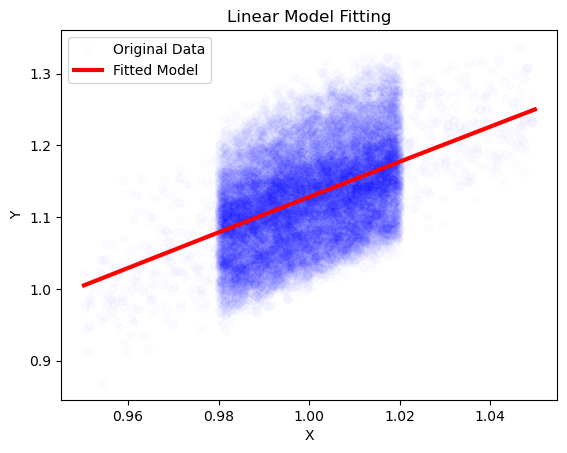

In [26]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X_torch, Y_torch, color="blue", label="Original Data", alpha=1e-2)

# Plotting the model's predictions
plt.plot(X_torch, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Model Fitting")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

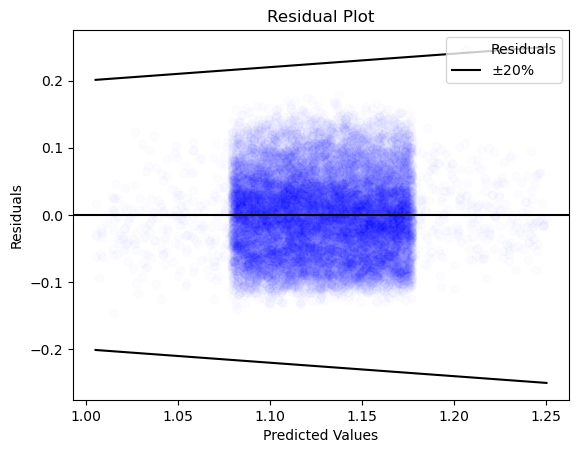

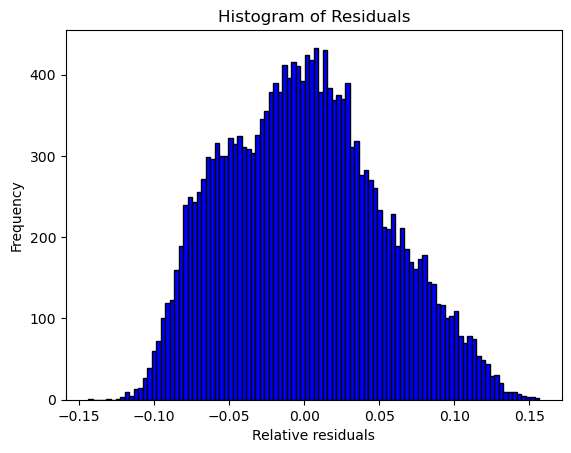

In [27]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy().flatten()
residuals_np = residuals.numpy().flatten()

# Plotting residuals
plt.figure()
plt.scatter(predictions_np, residuals_np, color="blue", alpha=1e-2, label="Residuals")
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.2 * x, color="k", label="$\pm$20%")
plt.plot(x, -0.2 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np / abs(predictions_np), bins=100, color="blue", edgecolor="black")
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

The 3/4 scaling is not easy to tell from linear in this narrow range of X.

## Single factor Vtot

In [28]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc))).flatten()
arg = np.argsort(X)
X = X[arg]
Y = dat["U_i"][mask].flatten()
Y = Y[arg]

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.a * x ** (3 / 4) + self.b


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b.item()

print(f"Exponential model: Y = {a} * X^(3/4) + {b}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 1.0955
Epoch [2/1000], Loss: 1.0001
Epoch [3/1000], Loss: 0.9999
Epoch [4/1000], Loss: 0.9999
Epoch [5/1000], Loss: 0.9999
Epoch [6/1000], Loss: 0.9999
Epoch [7/1000], Loss: 0.9999
Epoch [8/1000], Loss: 0.9999
Final Loss: 0.9999
Exponential model: Y = -0.020416829735040665 * X^(3/4) + 1.1489499807357788
R^2 Score: 6.0017680227675285e-05


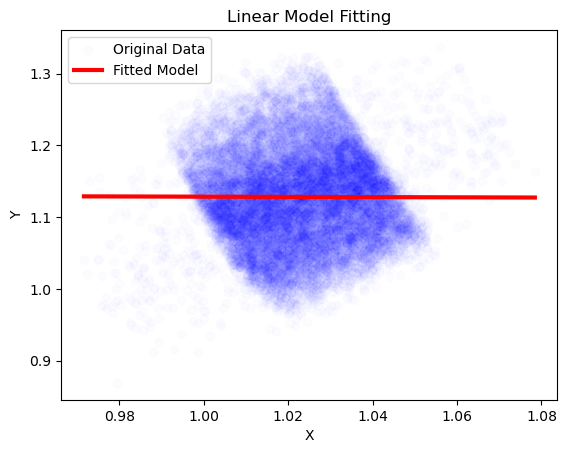

In [30]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X_torch, Y_torch, color="blue", label="Original Data", alpha=1e-2)

# Plotting the model's predictions
plt.plot(X_torch, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Model Fitting")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

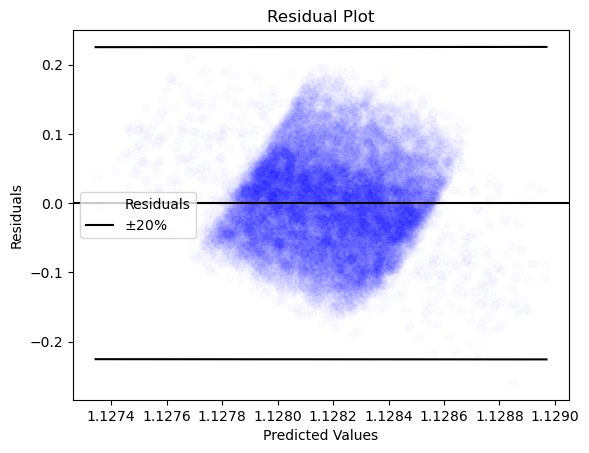

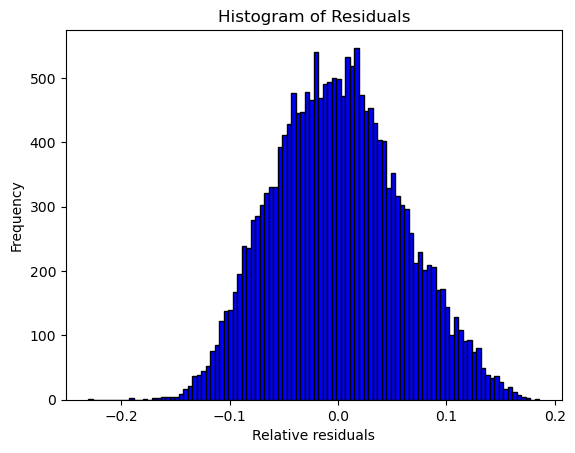

In [31]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy().flatten()
residuals_np = residuals.numpy().flatten()

# Plotting residuals
plt.figure()
plt.scatter(predictions_np, residuals_np, color="blue", alpha=1e-2, label="Residuals")
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.2 * x, color="k", label="$\pm$20%")
plt.plot(x, -0.2 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np / abs(predictions_np), bins=100, color="blue", edgecolor="black")
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

## Include neighbor number and trap spacing

The trap spacing and neighbor number basically affect how spread out the Wannier functions are, then affects U. 

In [53]:
X = dat["V_offset"][mask]
Y = dat["U_i"][mask]

In [54]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn((2,)))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = self.a[0] * x["nn"][None] + self.a[1]
        b = self.b[0] * x["nn"][None] + self.b[1]
        c = self.c[0] * x["nn"][None] + self.c[1]
        return a * x["V_offset"] ** (3 / 4) + b * x["avgr"] + c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["V_offset"] = torch.tensor(X, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
b = model.b
c = model.c

print(
    f"Exponential model: Y = ({a[0]} * nno + {a[1]}) * X ^ (3/4) + ({b[0]} * nno + {b[1]}) * avgr + ({c[0]} * nno + {c[1]})"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 2.2430
Epoch [2/1000], Loss: 0.0300
Epoch [3/1000], Loss: 0.0274
Epoch [4/1000], Loss: 0.0274
Epoch [5/1000], Loss: 0.0274
Epoch [6/1000], Loss: 0.0274
Epoch [7/1000], Loss: 0.0274
Epoch [8/1000], Loss: 0.0274
Epoch [9/1000], Loss: 0.0274
Epoch [10/1000], Loss: 0.0274
Epoch [11/1000], Loss: 0.0274
Epoch [12/1000], Loss: 0.0274
Epoch [13/1000], Loss: 0.0274
Epoch [14/1000], Loss: 0.0274
Epoch [15/1000], Loss: 0.0274
Epoch [16/1000], Loss: 0.0274
Epoch [17/1000], Loss: 0.0274
Epoch [18/1000], Loss: 0.0274
Epoch [19/1000], Loss: 0.0274
Epoch [20/1000], Loss: 0.0274
Final Loss: 0.0274
Exponential model: Y = (0.03191637992858887 * nno + 2.4153573513031006) * X ^ (3/4) + (0.10426909476518631 * nno + 0.7008549571037292) * avgr + (-0.2704086899757385 * nno + -2.169776439666748)
R^2 Score: 0.9725538758898353


The X slope dependence on nno is not obvious ~1e-2.

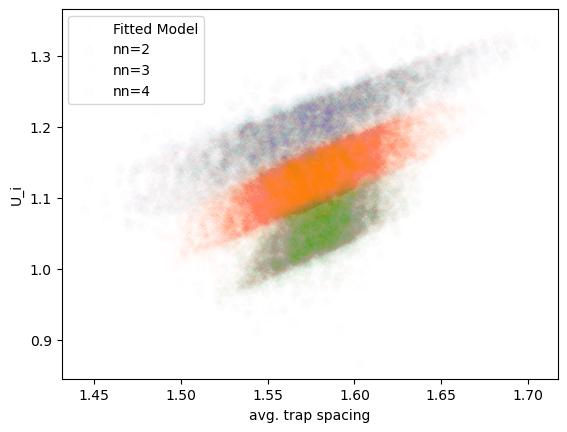

In [40]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(avgr, predicted, color="red", label="Fitted Model", marker=".", alpha=8e-3)
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        avgr[:, nno == i], Y[:, nno == i].flatten(), alpha=8e-3, label=f"nn={i}"
    )

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

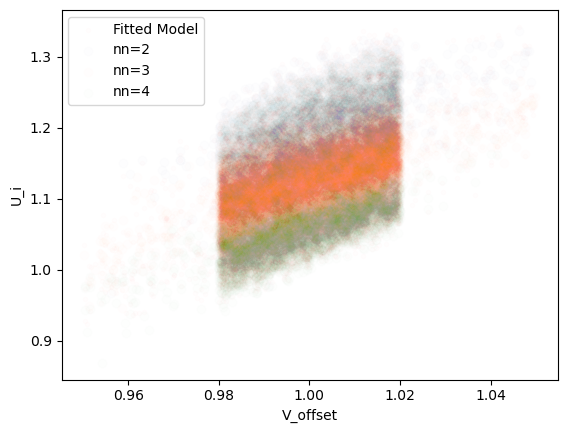

In [43]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=8e-3)
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=8e-3, label=f"nn={i}")

plt.xlabel("V_offset")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

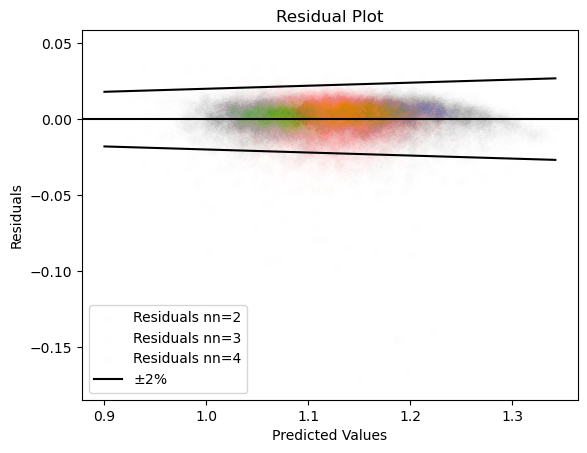

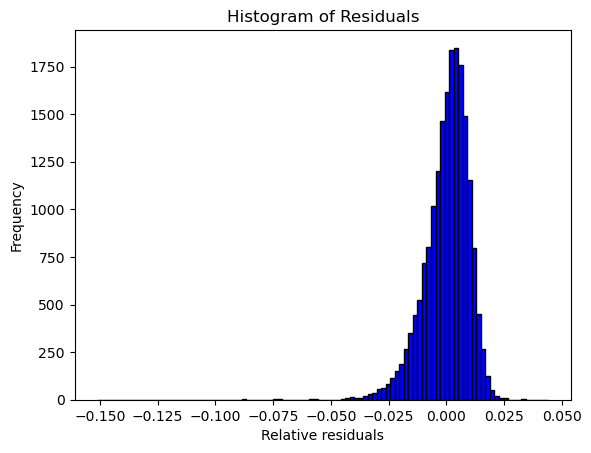

In [58]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=5e-3,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0.9, np.max(predictions_np), 100)
plt.plot(x, 0.02 * x, color="k", label="$\pm$2%")
plt.plot(x, -0.02 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

## Model but with total trap depth

In [45]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
Y = dat["U_i"][mask]

In [46]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = self.a
        b = self.b[0] * x["nn"][None] + self.b[1]
        c = self.c[0] * x["nn"][None] + self.c[1]
        return a * x["vtot"] ** (3 / 4) + b * x["avgr"] + c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=100000, tol=1e-9):
    # optimizer = optim.Adam(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if abs(loss_old - loss_new) < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b
c = model.c

print(
    f"Exponential model: Y = {a} * X ^ (3/4) + ({b[0]} * nno + {b[1]}) * avgr + {c[0]} * nno + {c[1]}"
)
print(f"R^2 Score: {r2}")

Epoch [1/100000], Loss: 0.0351
Epoch [2/100000], Loss: 0.0351
Epoch [3/100000], Loss: 0.0351
Epoch [4/100000], Loss: 0.0351
Epoch [5/100000], Loss: 0.0351
Final Loss: 0.0351
Exponential model: Y = 2.4358291625976562 * X ^ (3/4) + (0.18115487694740295 * nno + 0.7190030813217163) * avgr + -0.37338998913764954 * nno + -2.2187931537628174
R^2 Score: 0.9649259889449654


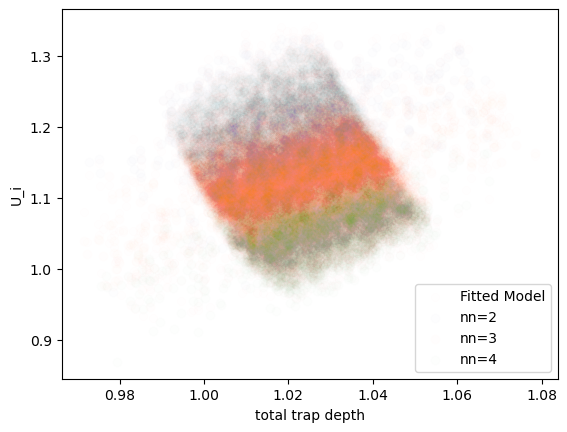

In [50]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", alpha=2e-3)
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=8e-3, label=f"nn={i}")

plt.xlabel("total trap depth")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

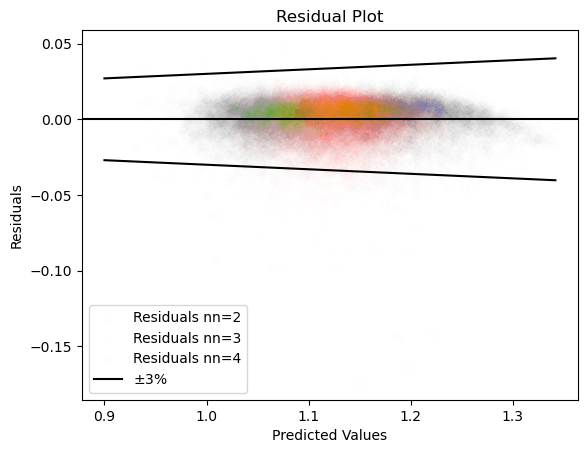

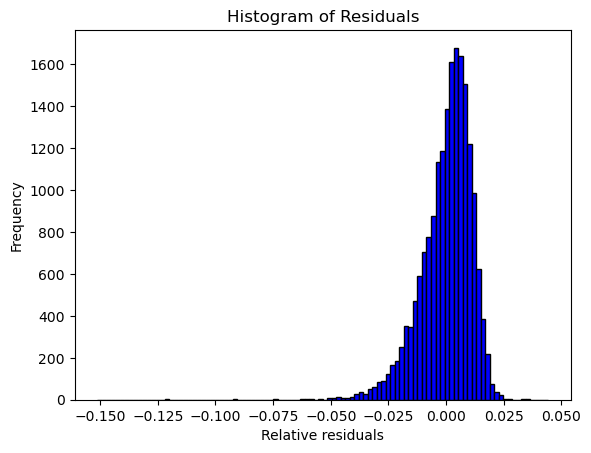

In [52]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=5e-3,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0.9, np.max(predictions_np), 100)
plt.plot(x, 0.02 * x, color="k", label="$\pm$2%")
plt.plot(x, -0.02 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

Model with total trap depth is not more effective than single trap depth.

## Model with harmonic approximation?

Using 3D harmonic approximation, we can write the harmonic potential near the minimal point

$$ V(r) = A (r + \frac{B}{2 A})^2 + Dz^2 - \frac{B^2}{4 A} - C $$

where,

$$ A = \frac{2V_0}{w^2} - \sum_i \frac{2V_i (4a^2_i - w^2)}{w^4} e^{-2a^2_i / w^2} > 0 $$

$$ B = \sum_i \frac{4V_i a_i}{w^2} e^{-2a^2_i / w^2} $$

$$ C = V_0 + \sum_i V_i e^{-2a^2_i / w^2} = V_{tot} $$

$$ D = \frac{V_0}{z^2_R} - \sum_i \frac{V_i (2a^2_i - w^2)}{w^2z^2_R} e^{-2a^2_i / w^2} $$

For the wavefunction calculation we can ignore the constant term at the end. Also, we only need to know the dependence of A and D on all the parameters.

NOTE: we ignore the xy cross term by the same reason as in interaction model. But with restoring the complexity we still keep anisotropy by the z term.

By translation we know the trap parameters are:

$$ \omega_r = \sqrt{\frac{2A}{m}} \quad \omega_z = \sqrt{\frac{2D}{m}} $$

$$ L_r = \sqrt{\frac{\hbar}{m \omega}} = \sqrt{\frac{\hbar}{\sqrt{2 m A}}} \quad L_z = \sqrt{\frac{\hbar}{\sqrt{2 m D}}} $$

The wavefunction solved on this trap is:

$$ \psi(r,z) = \frac{1}{\sqrt{\sqrt{\pi^3}L^2_rL_z}} e^{-\frac{r^2}{2L^2_r}-\frac{z^2}{2L^2_z}} $$

The U integral is:

$$ U = \frac{4\pi\hbar^2a_s}{m} \int \psi^4 d^3r 
= \frac{\sqrt{2}\hbar^2a_s}{\sqrt{\pi}m} \frac{1}{L^2_rL_z} 
= \frac{\sqrt{2}\hbar^2a_s}{\sqrt{\pi}m} \left(\frac{2 m}{\hbar}\right)^{3/4} \left(A^2D\right)^{1/4}
= a_s \left(\frac{32 \hbar^5}{\pi^2m} A^2D\right)^{1/4} $$

Consider the small fluctuation limit $V_i=V_0 + \delta V_i$ and $a_i=\bar{a} + \delta a_i$:

$$ A \approx \frac{2 w^2 V_{tot} - 8 \bar{a}^2 (V_{tot} - V_0)}{w^4} $$

$$ D \approx \frac{w^2 V_{tot} - 2 \bar{a}^2 (V_{tot} - V_0)}{w^2 z^2_R} $$

So the relation is:

$$ U = 4 a_s \left(\frac{\hbar^5}{2\pi^2m} \frac{[w^2 V_{tot} - 4 \bar{a}^2 (V_{tot} - V_0)]^2 [w^2 V_{tot} - 2 \bar{a}^2 (V_{tot} - V_0)]}{w^{10} z^2_R} \right)^{1/4} $$

We write the model as:

$$ U = c_3 \left([(c_1 - \bar{a}^2) V_{tot} + \bar{a}^2 V_0]^2 [(c_2 - \bar{a}^2) V_{tot} + \bar{a}^2 V_0]\right)^{1/4} $$

And the initial guess is:

$$ c_1 = \frac{w^2}{4} = 0.25 (\mathrm{\mu m^2}) $$

$$ c_2 = \frac{w^2}{2} = 0.5 (\mathrm{\mu m^2}) $$

$$ c_3 = 8 a_s \left(\frac{\hbar^5 V^3_\text{unit}}{4\pi^2mw^{10} z^2_R} \right)^{1/4} = 8.026 (\mathrm{kHz\cdot\mu m^{-3/2}})$$

In [5]:
Voff = dat["V_offset"][mask]
Vtot = dat["V_tot"][mask]
Y = dat["U_i"][mask]

In [6]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(0.25 * torch.ones(1))  # Initialize the 'c1' parameter
        self.b = nn.Parameter(0.5 * torch.ones(1))  # Initialize the 'c2' parameter
        self.c = nn.Parameter(
            torch.tensor([8.026 / 3])
        )  # Initialize the 'c3' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = (self.a - x["avgr"] ** 2) * x["vtot"] + x["avgr"] ** 2 * x["voff"]
        b = (self.b - x["avgr"] ** 2) * x["vtot"] + x["avgr"] ** 2 * x["voff"]
        return self.c * (a**2 * b) ** (1 / 4)


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(Vtot, dtype=torch.float64)
X_torch["voff"] = torch.tensor(Voff, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.Adam(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if abs(loss_old - loss_new) < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b.item()
c = model.c.item()

print(f"Model: Y = {a} {b} {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0560
Epoch [2/1000], Loss: 0.0501
Epoch [3/1000], Loss: 0.0496
Epoch [4/1000], Loss: 0.0493
Epoch [5/1000], Loss: 0.0493
Epoch [6/1000], Loss: 0.0493
Epoch [7/1000], Loss: 0.0493
Epoch [8/1000], Loss: 0.0493
Epoch [9/1000], Loss: 0.0493
Epoch [10/1000], Loss: 0.0493
Epoch [11/1000], Loss: 0.0493
Epoch [12/1000], Loss: 0.0493
Epoch [13/1000], Loss: 0.0493
Epoch [14/1000], Loss: 0.0493
Epoch [15/1000], Loss: 0.0493
Epoch [16/1000], Loss: 0.0493
Epoch [17/1000], Loss: 0.0493
Epoch [18/1000], Loss: 0.0493
Epoch [19/1000], Loss: 0.0493
Epoch [20/1000], Loss: 0.0493
Epoch [21/1000], Loss: 0.0493
Final Loss: 0.0493
Model: Y = 0.23838336765766144 0.2414889633655548 3.9333174228668213
R^2 Score: 0.9506656301295169


Text(0.5, 1.0, 'Histogram of Residuals')

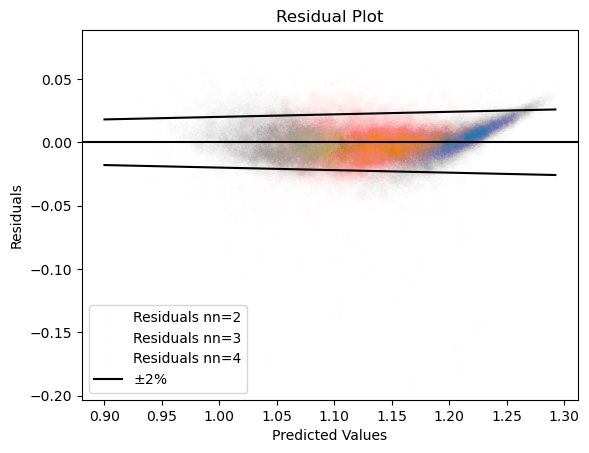

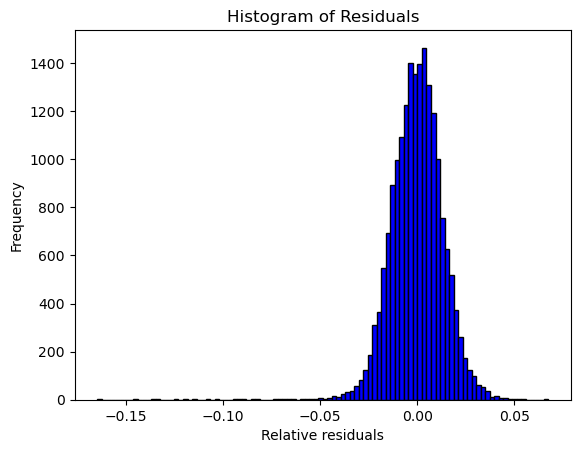

In [21]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=5e-3,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0.9, np.max(predictions_np), 100)
plt.plot(x, 0.02 * x, color="k", label="$\pm$2%")
plt.plot(x, -0.02 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

The variance is ~2x the previous model with 3 parameters, rather than 5.

We notice a steady shift for nnn=2 at large predicted U value. So the model seems to need a correction.

Note that this model doesn't take fully into account the number of n.n. This is only included in the total trap depth. We may need a correction on that.